In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
from io import StringIO
import time

URL = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics"
TAB_NAME = "Attacking"

options = webdriver.ChromeOptions()
options.add_argument("--window-size=1400,1000")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

try:
    print(f"Opening {URL}")
    driver.get(URL)

    wait = WebDriverWait(driver, 20)
    wait.until(EC.presence_of_element_located((By.TAG_NAME, "table")))

    cookie_texts = ["Accept", "Accept All", "I Accept", "Agree", "Got it"]
    for text in cookie_texts:
        try:
            btn = driver.find_element(By.XPATH, f"//button[contains(text(), '{text}')]")
            btn.click()
            print(f"Dismissed cookie banner: '{text}'")
            time.sleep(1)
            break
        except Exception:
            pass

    print(f"Looking for '{TAB_NAME}' tab...")
    tab_button = wait.until(
        EC.presence_of_element_located((By.XPATH, f"//*[contains(text(), '{TAB_NAME}')]"))
    )

    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", tab_button)
    time.sleep(1)

    driver.execute_script("arguments[0].click();", tab_button)
    print("Clicked via JavaScript")

    time.sleep(3)

    html = driver.page_source
    tables = pd.read_html(StringIO(html))

    print(f"\nFound {len(tables)} table(s) on the page:")
    for i, t in enumerate(tables):
        print(f"Table {i}: shape={t.shape}, columns={t.columns.tolist()[:8]}")

finally:
    driver.quit()

Opening https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics
Looking for 'Attacking' tab...
Clicked via JavaScript

Found 1 table(s) on the page:
Table 0: shape=(50, 12), columns=['Rank', 'Player', 'Assists', 'Attempts On Target', 'Attempts At Goal', 'Attempts At Goal Conv. Rate (%)', 'Attempts Inside the Penalty Area', 'Attempts Outside the Penalty Area']


In [7]:
df = tables[0]
df.to_csv("fifa_attacking_stats_real.csv", index=False)
print("Saved! Shape:", df.shape)
df.head(10)

Saved! Shape: (50, 12)


,Rank,Player,Assists,Attempts On Target,Attempts At Goal,Attempts At Goal Conv. Rate (%),Attempts Inside the Penalty Area,Attempts Outside the Penalty Area,Headed Attempts at Goal,xG,xG Efficiency,Corners
0,1,Michael OliseFRAFRAFW,7,5,20,0,10,10,0,2.34,0x,25
1,2,Martin OdegaardNORNORMF,4,3,9,0,5,4,0,0.72,0x,12
2,2,Kylian MbappeFRAFRAFW,4,23,41,24,27,14,0,6.54,1.53x,5
3,2,Brahim DiazMARMARFW,4,1,6,0,4,2,0,0.31,0x,1
4,2,Bruno GuimaraesBRABRAMF,4,2,8,0,5,3,1,1.02,0x,8
5,2,Lionel MessiARGARGFW,4,19,35,23,16,19,0,6.18,1.29x,38
6,7,Roberto AlvaradoMEXMEXFW,3,0,5,0,2,3,0,0.28,0x,14
7,7,Anthony GordonENGENGFW,3,4,6,17,6,0,2,0.70,1.43x,0
8,7,Florian WirtzGERGERMF,3,1,10,0,5,5,0,0.97,0x,5
9,7,Andreas SchjelderupNORNORMF,3,2,3,33,3,0,0,0.20,5.12x,0


In [8]:
print(df.columns.tolist())
print(df.dtypes)
df.head(3)

['Rank', 'Player', 'Assists', 'Attempts On Target', 'Attempts At Goal', 'Attempts At Goal Conv. Rate (%)', 'Attempts Inside the Penalty Area', 'Attempts Outside the Penalty Area', 'Headed Attempts at Goal', 'xG', 'xG Efficiency', 'Corners']
Rank                                   int64
Player                                   str
Assists                                int64
Attempts On Target                     int64
Attempts At Goal                       int64
Attempts At Goal Conv. Rate (%)        int64
Attempts Inside the Penalty Area       int64
Attempts Outside the Penalty Area      int64
Headed Attempts at Goal                int64
xG                                   float64
xG Efficiency                            str
Corners                                int64
dtype: object


,Rank,Player,Assists,Attempts On Target,Attempts At Goal,Attempts At Goal Conv. Rate (%),Attempts Inside the Penalty Area,Attempts Outside the Penalty Area,Headed Attempts at Goal,xG,xG Efficiency,Corners
0,1,Michael OliseFRAFRAFW,7,5,20,0,10,10,0,2.34,0x,25
1,2,Martin OdegaardNORNORMF,4,3,9,0,5,4,0,0.72,0x,12
2,2,Kylian MbappeFRAFRAFW,4,23,41,24,27,14,0,6.54,1.53x,5


In [9]:
import pandas as pd
import re

df = pd.read_csv("fifa_attacking_stats_real.csv")

pattern = re.compile(r'^(?P<player>.+?)(?P<nation>[A-Z]{3})(?P=nation)(?P<position>FW|MF|DF|GK)$')

def split_player(text):
    m = pattern.match(text)
    if m:
        return pd.Series([m.group('player'), m.group('nation'), m.group('position')])
    else:
        return pd.Series([text, None, None])

df[['player_name', 'nation', 'position']] = df['Player'].apply(split_player)

# Drop the original messy column, keep the clean ones
df = df.drop(columns=['Player'])

print(df[['player_name', 'nation', 'position']].head(10))
print("\nAny unmatched rows:", df['nation'].isna().sum())

           player_name nation position
0        Michael Olise    FRA       FW
1      Martin Odegaard    NOR       MF
2        Kylian Mbappe    FRA       FW
3          Brahim Diaz    MAR       FW
4      Bruno Guimaraes    BRA       MF
5         Lionel Messi    ARG       FW
6     Roberto Alvarado    MEX       FW
7       Anthony Gordon    ENG       FW
8        Florian Wirtz    GER       MF
9  Andreas Schjelderup    NOR       MF

Any unmatched rows: 0


In [10]:
print("Raw records:", len(df))
print("Missing values:\n", df.isna().sum())

# Exclude players with 0 attempts at goal (can't compute a meaningful conversion rate)
df_clean = df[df['Attempts At Goal'] > 0].copy()
print(f"\nExcluded {len(df) - len(df_clean)} players with 0 attempts at goal")
print("Population size (sampling frame):", len(df_clean))
print("Population mean conversion rate:", df_clean['Attempts At Goal Conv. Rate (%)'].mean())

Raw records: 50
Missing values:
 Rank                                 0
Assists                              0
Attempts On Target                   0
Attempts At Goal                     0
Attempts At Goal Conv. Rate (%)      0
Attempts Inside the Penalty Area     0
Attempts Outside the Penalty Area    0
Headed Attempts at Goal              0
xG                                   0
xG Efficiency                        0
Corners                              0
player_name                          0
nation                               0
position                             0
dtype: int64

Excluded 1 players with 0 attempts at goal
Population size (sampling frame): 49
Population mean conversion rate: 13.714285714285714


In [11]:
import numpy as np

np.random.seed(42)
n = 30
sample = df_clean.sample(n=n, random_state=42)

print(f"Simple random sample, n={n}")
print(sample[['player_name', 'position', 'Attempts At Goal', 'Attempts At Goal Conv. Rate (%)']].head(10))

Simple random sample, n=30
         player_name position  Attempts At Goal  \
13    Johan Manzambi       MF                 6   
46      Ismaila Sarr       FW                17   
48   Soufiane Rahimi       FW                 6   
45   Nicolas Jackson       FW                 7   
17   Viktor Gyokeres       FW                12   
27   Denzel Dumfries       DF                 5   
26   Ousmane Dembele       FW                20   
25  Ryan Gravenberch       MF                 5   
31     Nathan Saliba       MF                 3   
19      Patrick Berg       MF                 3   

    Attempts At Goal Conv. Rate (%)  
13                               50  
46                               24  
48                               33  
45                                0  
17                                8  
27                                0  
26                               30  
25                                0  
31                               33  
19                             

In [12]:
from scipy import stats

rate = sample['Attempts At Goal Conv. Rate (%)']

print("=== STEP 4: DESCRIPTIVE STATISTICS ===")
print(rate.describe())
print("Skewness:", rate.skew())

print("\n=== STEP 5: 95% CONFIDENCE INTERVAL ===")
mean = rate.mean()
sem = stats.sem(rate)
ci = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=sem)
print(f"Sample mean: {mean:.2f}%")
print(f"95% CI: ({ci[0]:.2f}%, {ci[1]:.2f}%)")

print("\n=== STEP 6: ONE-SAMPLE T-TEST ===")
benchmark = 15.0
t_stat, p_value = stats.ttest_1samp(rate, popmean=benchmark)
print(f"H0: population mean conversion rate = {benchmark}%")
print(f"H1: population mean conversion rate != {benchmark}%")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
decision = "Reject H0" if p_value < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision}")

=== STEP 4: DESCRIPTIVE STATISTICS ===
count     30.000000
mean      13.933333
std       21.845750
min        0.000000
25%        0.000000
50%        0.000000
75%       23.750000
max      100.000000
Name: Attempts At Goal Conv. Rate (%), dtype: float64
Skewness: 2.3901459068018505

=== STEP 5: 95% CONFIDENCE INTERVAL ===
Sample mean: 13.93%
95% CI: (5.78%, 22.09%)

=== STEP 6: ONE-SAMPLE T-TEST ===
H0: population mean conversion rate = 15.0%
H1: population mean conversion rate != 15.0%
t-statistic: -0.2674
p-value: 0.7910
Decision at alpha=0.05: Fail to reject H0


In [13]:
print("=== EXTRA: TWO-SAMPLE T-TEST (Forwards vs Midfielders) ===")

fw_pop = df_clean[df_clean['position'] == 'FW']['Attempts At Goal Conv. Rate (%)']
mf_pop = df_clean[df_clean['position'] == 'MF']['Attempts At Goal Conv. Rate (%)']

print("FW population size:", len(fw_pop))
print("MF population size:", len(mf_pop))

n_fw = min(15, len(fw_pop))
n_mf = min(12, len(mf_pop))

fw_sample = fw_pop.sample(n=n_fw, random_state=42)
mf_sample = mf_pop.sample(n=n_mf, random_state=42)

print(f"\nFW sample (n={n_fw}) mean: {fw_sample.mean():.2f}%")
print(f"MF sample (n={n_mf}) mean: {mf_sample.mean():.2f}%")

levene_stat, levene_p = stats.levene(fw_sample, mf_sample)
equal_var = levene_p > 0.05
print(f"\nLevene's test p-value: {levene_p:.4f} -> equal_var={equal_var}")

t_stat2, p_value2 = stats.ttest_ind(fw_sample, mf_sample, equal_var=equal_var)
print(f"\nH0: mean conversion rate (FW) = mean conversion rate (MF)")
print(f"H1: mean conversion rate (FW) != mean conversion rate (MF)")
print(f"t-statistic: {t_stat2:.4f}")
print(f"p-value: {p_value2:.4f}")
decision2 = "Reject H0" if p_value2 < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision2}")

=== EXTRA: TWO-SAMPLE T-TEST (Forwards vs Midfielders) ===
FW population size: 25
MF population size: 15

FW sample (n=15) mean: 16.93%
MF sample (n=12) mean: 12.08%

Levene's test p-value: 0.8920 -> equal_var=True

H0: mean conversion rate (FW) = mean conversion rate (MF)
H1: mean conversion rate (FW) != mean conversion rate (MF)
t-statistic: 0.8026
p-value: 0.4298
Decision at alpha=0.05: Fail to reject H0


In [14]:
# Clean the xG Efficiency field (e.g. "1.53x" -> 1.53)
df['goal_xg_ratio'] = df['xG Efficiency'].str.replace('x', '', regex=False).astype(float)

# New population: players with a nonzero xG (shot quality) value
df_clean_xg = df[df['xG'] > 0].copy()

print("Population size:", len(df_clean_xg))
print("Population mean Goals/xG ratio:", df_clean_xg['goal_xg_ratio'].mean())

Population size: 49
Population mean Goals/xG ratio: 1.236530612244898


In [15]:
sample_xg = df_clean_xg.sample(n=30, random_state=42)
print(sample_xg[['player_name', 'position', 'xG', 'goal_xg_ratio']].head(10))

         player_name position    xG  goal_xg_ratio
13    Johan Manzambi       MF  0.63           4.73
46      Ismaila Sarr       FW  3.68           1.09
48   Soufiane Rahimi       FW  1.59           1.26
45   Nicolas Jackson       FW  0.56           0.00
17   Viktor Gyokeres       FW  1.39           0.72
27   Denzel Dumfries       DF  0.44           0.00
26   Ousmane Dembele       FW  2.10           2.86
25  Ryan Gravenberch       MF  0.25           0.00
31     Nathan Saliba       MF  0.30           3.36
19      Patrick Berg       MF  0.29           0.00


In [16]:
ratio = sample_xg['goal_xg_ratio']

print("=== DESCRIPTIVE STATISTICS ===")
print(ratio.describe())
print("Skewness:", ratio.skew())

print("\n=== 95% CONFIDENCE INTERVAL ===")
mean = ratio.mean()
sem = stats.sem(ratio)
ci = stats.t.interval(confidence=0.95, df=29, loc=mean, scale=sem)
print(f"Sample mean: {mean:.3f}   95% CI: ({ci[0]:.3f}, {ci[1]:.3f})")

print("\n=== ONE-SAMPLE T-TEST (vs 1.0) ===")
t_stat, p_value = stats.ttest_1samp(ratio, popmean=1.0)
print(f"t = {t_stat:.4f}, p = {p_value:.4f}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

=== DESCRIPTIVE STATISTICS ===
count    30.000000
mean      1.298667
std       2.506990
min       0.000000
25%       0.000000
50%       0.000000
75%       1.327500
max      12.330000
Name: goal_xg_ratio, dtype: float64
Skewness: 3.3200048240918747

=== 95% CONFIDENCE INTERVAL ===
Sample mean: 1.299   95% CI: (0.363, 2.235)

=== ONE-SAMPLE T-TEST (vs 1.0) ===
t = 0.6525, p = 0.5192
Decision: Fail to reject H0


In [17]:
fw_pop = df_clean_xg[df_clean_xg['position'] == 'FW']['goal_xg_ratio']
mf_pop = df_clean_xg[df_clean_xg['position'] == 'MF']['goal_xg_ratio']

fw_sample = fw_pop.sample(n=min(15, len(fw_pop)), random_state=42)
mf_sample = mf_pop.sample(n=min(12, len(mf_pop)), random_state=42)

print(f"FW mean: {fw_sample.mean():.3f}   MF mean: {mf_sample.mean():.3f}")

levene_stat, levene_p = stats.levene(fw_sample, mf_sample)
equal_var = levene_p > 0.05
print(f"Levene p = {levene_p:.4f} -> equal_var={equal_var}")

t_stat2, p_value2 = stats.ttest_ind(fw_sample, mf_sample, equal_var=equal_var)
print(f"t = {t_stat2:.4f}, p = {p_value2:.4f}")
print("Decision:", "Reject H0" if p_value2 < 0.05 else "Fail to reject H0")

FW mean: 1.051   MF mean: 1.225
Levene p = 0.2089 -> equal_var=True
t = -0.3481, p = 0.7307
Decision: Fail to reject H0


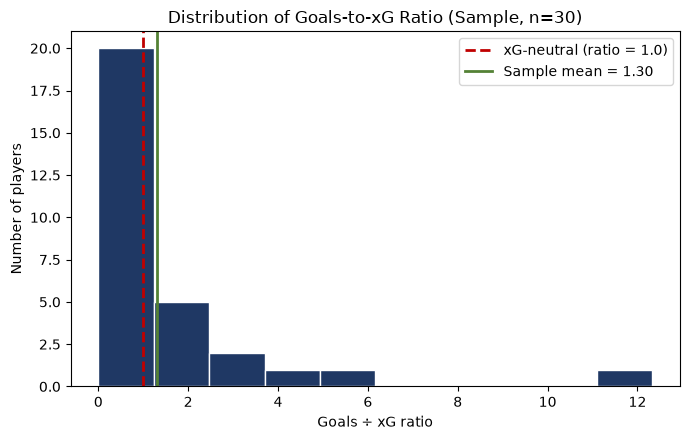

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sample_xg['goal_xg_ratio'], bins=10, color='#1F3864', edgecolor='white')
ax.axvline(1.0, color='#C00000', linestyle='--', linewidth=2, label='xG-neutral (ratio = 1.0)')
ax.axvline(sample_xg['goal_xg_ratio'].mean(), color='#548235', linestyle='-', linewidth=2, 
           label=f"Sample mean = {sample_xg['goal_xg_ratio'].mean():.2f}")
ax.set_xlabel('Goals ÷ xG ratio')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of Goals-to-xG Ratio (Sample, n=30)')
ax.legend()
plt.tight_layout()
plt.savefig('xg_ratio_distribution.png', dpi=150)
plt.show()